In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


##### EDA

In [5]:
df.shape

(918, 12)

In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: title={'center': 'HeartDisease count'}, xlabel='HeartDisease', ylabel='count'>

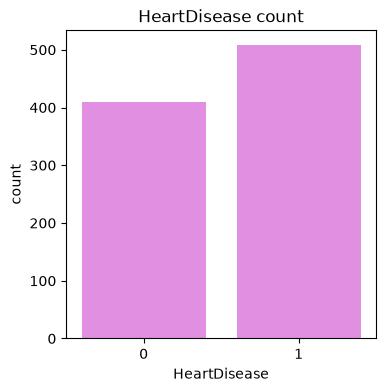

In [11]:
plt.figure(figsize=(4,4))
plt.title("HeartDisease count")
sns.countplot(data = df,x = "HeartDisease",color="violet")

In [12]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(data = df,x = var,kde = True)

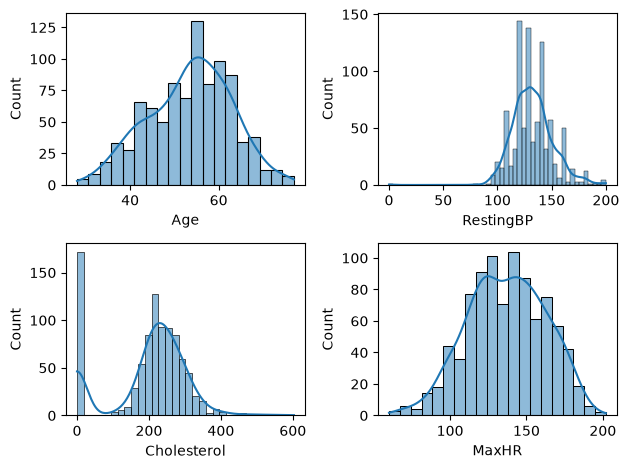

In [14]:
i = 1
for var in ['Age',  'RestingBP', 'Cholesterol','MaxHR' ] :
    plotting(var,i)
    i+=1

plt.tight_layout()

In [15]:
ch_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean().round(0)
ch_mean

np.float64(245.0)

In [16]:
df["Cholesterol"] = df["Cholesterol"].replace(to_replace = 0,value = ch_mean)

In [17]:
df["Cholesterol"].value_counts()

Cholesterol
245    178
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 221, dtype: int64

In [18]:
rest_bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean().round(0)
rest_bp_mean

np.float64(133.0)

In [19]:
df["RestingBP"] = df["RestingBP"].replace(to_replace = 0,value = rest_bp_mean)

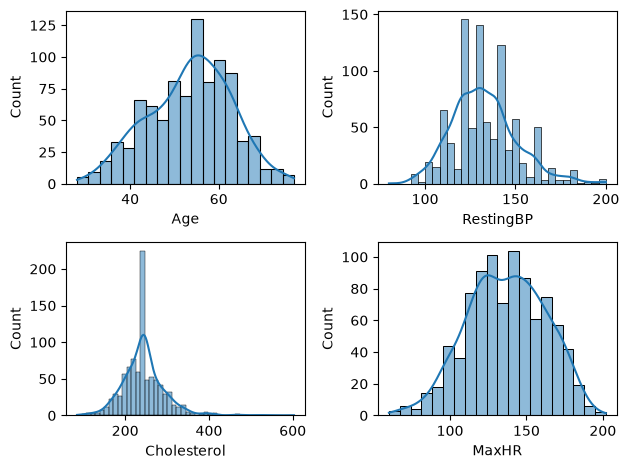

In [20]:
i = 1
for var in ['Age',  'RestingBP', 'Cholesterol','MaxHR' ] :
    plotting(var,i)
    i+=1

plt.tight_layout()

In [21]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [22]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [23]:
len(df["Oldpeak"].unique())

53

In [24]:
len(df["FastingBS"].unique())

2

In [25]:
def cat_countplot(var1,num,var2 = None):
    plt.subplot(2,2,num)
    sns.countplot(data = df,x = var1,hue = var2)

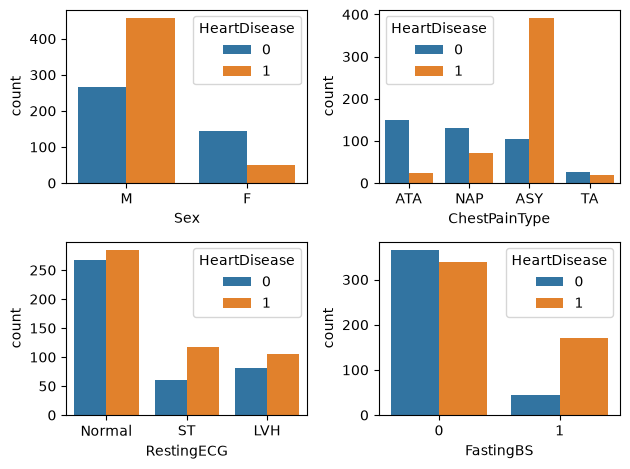

In [26]:

i = 1
for var in ['Sex', 'ChestPainType', 'RestingECG', 'FastingBS'] :
    cat_countplot(var,i,"HeartDisease")
    i+=1

plt.tight_layout()



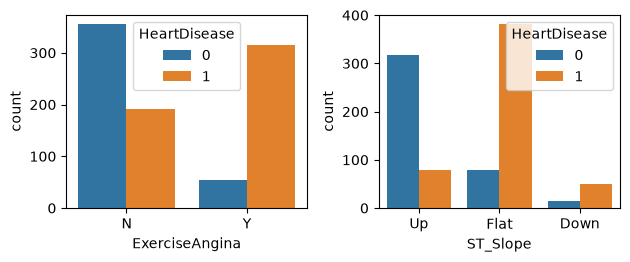

In [27]:
i = 1
for var in ['ExerciseAngina','ST_Slope'] :
    cat_countplot(var,i,"HeartDisease")
    i+=1

plt.tight_layout()


<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

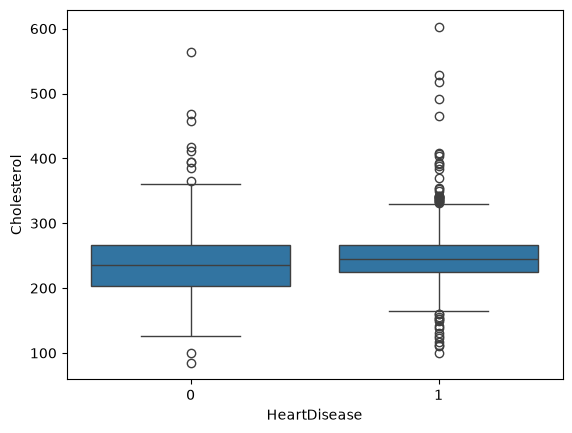

In [28]:
sns.boxplot(data = df,y = "Cholesterol",x = "HeartDisease")

<Axes: xlabel='HeartDisease', ylabel='Age'>

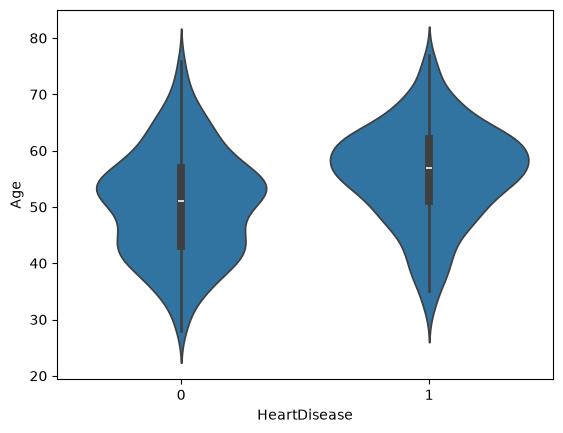

In [29]:
sns.violinplot(x = df["HeartDisease"],y = df["Age"])

<Axes: >

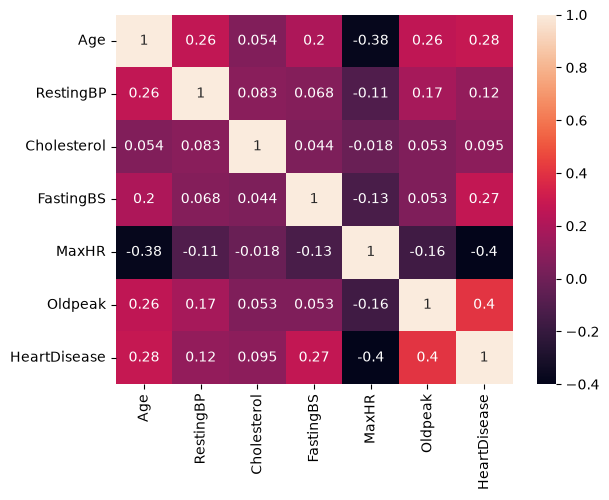

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

##### Data Preprocessing & Cleaning

In [31]:
df_encode = pd.get_dummies(data = df)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,True,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,False,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,True,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,False,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,False,True,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,True,False,False,False,True,False,True,False,True,False,False,True,False
914,68,144,193,1,141,3.4,1,False,True,True,False,False,False,False,True,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,False,True,True,False,False,False,False,True,False,False,True,False,True,False
916,57,130,236,0,174,0.0,1,True,False,False,True,False,False,True,False,False,True,False,False,True,False


In [32]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

##### Feature Engineering and Selection

In [33]:
df_encode.drop(labels = ['Sex_M','ExerciseAngina_N'],axis = 1,inplace = True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,False,True,False,False,False,True,False,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,True,False,False,True,False,False,False,True,False
2,37,130,283,0,98,0.0,0,False,False,True,False,False,False,False,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,True,False,False,False,False,True,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,False,False,True,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,False,False,False,True,False,True,False,False,False,True,False
914,68,144,193,1,141,3.4,1,False,True,False,False,False,False,True,False,False,False,True,False
915,57,130,131,0,115,1.2,1,False,True,False,False,False,False,True,False,True,False,True,False
916,57,130,236,0,174,0.0,1,True,False,True,False,False,True,False,False,False,False,True,False


In [34]:
df_encode.rename(columns= {"Sex_F" : "is_female","ExerciseAngina_Y" : "is_ExerciseAngina"},inplace=True)

In [35]:
df_encode = df_encode.astype(int)
df_encode 



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,is_female,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,is_ExerciseAngina,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,0,1,0,0,0,1,0,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,1,0,0,1,0,0,0,1,0
2,37,130,283,0,98,0,0,0,0,1,0,0,0,0,1,0,0,0,1
3,48,138,214,0,108,1,1,1,1,0,0,0,0,1,0,1,0,1,0
4,54,150,195,0,122,0,0,0,0,0,1,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,0,0,0,0,1,0,1,0,0,0,1,0
914,68,144,193,1,141,3,1,0,1,0,0,0,0,1,0,0,0,1,0
915,57,130,131,0,115,1,1,0,1,0,0,0,0,1,0,1,0,1,0
916,57,130,236,0,174,0,1,1,0,1,0,0,1,0,0,0,0,1,0


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_columns = ["Age","RestingBP","Cholesterol","MaxHR","Oldpeak"]

df_encode[numeric_columns] = scaler.fit_transform(df_encode[numeric_columns])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,is_female,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,is_ExerciseAngina,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.831244,0,1.382928,-0.727592,0,0,0,1,0,0,0,1,0,0,0,0,1
1,-0.478484,1.527163,-1.214200,0,0.754157,0.282891,1,1,0,0,1,0,0,1,0,0,0,1,0
2,-1.751359,-0.141345,0.718651,0,-1.525138,-0.727592,0,0,0,1,0,0,0,0,1,0,0,0,1
3,-0.584556,0.303591,-0.576172,0,-1.132156,0.282891,1,1,1,0,0,0,0,1,0,1,0,1,0
4,0.051881,0.970994,-0.932717,0,-0.581981,-0.727592,0,0,0,0,1,0,0,1,0,0,0,0,1


In [37]:
from scipy.stats import pearsonr

corealtion = {
    feature : pearsonr(x = df_encode[feature],y = df_encode["HeartDisease"])[0]
    for feature in numeric_columns 
}
corealtion


{'Age': np.float64(0.28203850581899725),
 'RestingBP': np.float64(0.1179630169319873),
 'Cholesterol': np.float64(0.0949228162400108),
 'MaxHR': np.float64(-0.40042076946319016),
 'Oldpeak': np.float64(0.39238540391984345)}

In [38]:
corelation_df = pd.DataFrame(data = list(corealtion.items()),columns=["feature","pearsonr corelation with Heartdisease"])
corelation_df.sort_values(by = "pearsonr corelation with Heartdisease",ascending=False)

,feature,pearsonr corelation with Heartdisease
4,Oldpeak,0.392385
0,Age,0.282039
1,RestingBP,0.117963
2,Cholesterol,0.094923
3,MaxHR,-0.400421


In [39]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,is_female,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,is_ExerciseAngina,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.831244,0,1.382928,-0.727592,0,0,0,1,0,0,0,1,0,0,0,0,1
1,-0.478484,1.527163,-1.214200,0,0.754157,0.282891,1,1,0,0,1,0,0,1,0,0,0,1,0
2,-1.751359,-0.141345,0.718651,0,-1.525138,-0.727592,0,0,0,1,0,0,0,0,1,0,0,0,1
3,-0.584556,0.303591,-0.576172,0,-1.132156,0.282891,1,1,1,0,0,0,0,1,0,1,0,1,0
4,0.051881,0.970994,-0.932717,0,-0.581981,-0.727592,0,0,0,0,1,0,0,1,0,0,0,0,1


In [40]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_res = {}

cat_features = ['is_female', 'ChestPainType_ASY','ChestPainType_ATA','ChestPainType_NAP',
                'ChestPainType_TA', 'RestingECG_LVH','RestingECG_Normal','RestingECG_ST',
                'is_ExerciseAngina', 'FastingBS','ST_Slope_Down',	'ST_Slope_Flat'	,'ST_Slope_Up'] 

for col in cat_features :
    stats,p_value,_,_ = chi2_contingency(pd.crosstab(df_encode[col],df_encode["HeartDisease"]))

    decision = None
    if p_value < alpha :
        decision = "Reject Null Keep Feature"
    else :
        decision = "Accept Null drop Feature"

    chi2_res[col] = {
        "chi2_stat" : stats,
        "p_value" : p_value,
        "decision" : decision
    }

chi2_res


{'is_female': {'chi2_stat': np.float64(84.14510134633774),
  'p_value': np.float64(4.5976174508091984e-20),
  'decision': 'Reject Null Keep Feature'},
 'ChestPainType_ASY': {'chi2_stat': np.float64(243.02113844518294),
  'p_value': np.float64(8.629373889117522e-55),
  'decision': 'Reject Null Keep Feature'},
 'ChestPainType_ATA': {'chi2_stat': np.float64(146.23632341405644),
  'p_value': np.float64(1.1525973044710748e-33),
  'decision': 'Reject Null Keep Feature'},
 'ChestPainType_NAP': {'chi2_stat': np.float64(40.60871072656936),
  'p_value': np.float64(1.8597575246926214e-10),
  'decision': 'Reject Null Keep Feature'},
 'ChestPainType_TA': {'chi2_stat': np.float64(2.2738021313990893),
  'p_value': np.float64(0.13157675122814316),
  'decision': 'Accept Null drop Feature'},
 'RestingECG_LVH': {'chi2_stat': np.float64(0.05809770425682549),
  'p_value': np.float64(0.8095282584405755),
  'decision': 'Accept Null drop Feature'},
 'RestingECG_Normal': {'chi2_stat': np.float64(7.327531747913

In [41]:
chi2_contingency_table = pd.DataFrame(data = chi2_res)
chi2_contingency_table.T.sort_values(by="p_value")

,chi2_stat,p_value,decision
ST_Slope_Up,352.823905,0.0,Reject Null Keep Feature
ST_Slope_Flat,279.659914,0.0,Reject Null Keep Feature
ChestPainType_ASY,243.021138,0.0,Reject Null Keep Feature
is_ExerciseAngina,222.259383,0.0,Reject Null Keep Feature
ChestPainType_ATA,146.236323,0.0,Reject Null Keep Feature
is_female,84.145101,0.0,Reject Null Keep Feature
FastingBS,64.320679,0.0,Reject Null Keep Feature
ChestPainType_NAP,40.608711,0.0,Reject Null Keep Feature
ST_Slope_Down,12.824125,0.000342,Reject Null Keep Feature
RestingECG_ST,9.135266,0.002507,Reject Null Keep Feature


In [42]:
chi2_contingency_table.columns

Index(['is_female', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'is_ExerciseAngina', 'FastingBS',
       'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [43]:
numeric_columns

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

In [44]:
final_feature = ['is_female', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'RestingECG_Normal', 'RestingECG_ST',
         'is_ExerciseAngina', 'FastingBS', 'ST_Slope_Flat', 'ST_Slope_Up',
         'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak','HeartDisease']

final_df = df_encode[final_feature]
final_df.head()

,is_female,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,is_ExerciseAngina,FastingBS,ST_Slope_Flat,ST_Slope_Up,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease
0,0,0,1,0,1,0,0,0,0,1,-1.433140,0.414825,0.831244,1.382928,-0.727592,0
1,1,0,0,1,1,0,0,0,1,0,-0.478484,1.527163,-1.214200,0.754157,0.282891,1
2,0,0,1,0,0,1,0,0,0,1,-1.751359,-0.141345,0.718651,-1.525138,-0.727592,0
3,1,1,0,0,1,0,1,0,1,0,-0.584556,0.303591,-0.576172,-1.132156,0.282891,1
4,0,0,0,1,1,0,0,0,0,1,0.051881,0.970994,-0.932717,-0.581981,-0.727592,0


In [45]:
# from sklearn.feature_selection import mutual_info_classif

# X = df_encode.drop("HeartDisease", axis=1)
# y = df_encode["HeartDisease"]

# mi = mutual_info_classif(X, y)

# pd.Series(mi, index=X.columns).sort_values(ascending=False)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report,f1_score,accuracy_score

In [47]:
from sklearn.model_selection import train_test_split
X = final_df.drop("HeartDisease",axis = 1)
y = final_df["HeartDisease"]

In [48]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [52]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "DT" : DecisionTreeClassifier(random_state=42),
    "Naive Bayes" : GaussianNB(),
    "SVM" : SVC()
}

In [59]:
result = []

In [60]:
for name,model in models.items() :
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    f1 = f1_score(y_test,y_pred)
    acc = accuracy_score(y_test,y_pred)
    result.append({
       "model" : name,
       "Accuracy" : round(acc,4),
       "f1_score" : round(f1,4)
    })

In [61]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.8696, 'f1_score': 0.8846},
 {'model': 'KNN', 'Accuracy': 0.8533, 'f1_score': 0.8683},
 {'model': 'DT', 'Accuracy': 0.8261, 'f1_score': 0.8351},
 {'model': 'Naive Bayes', 'Accuracy': 0.8424, 'f1_score': 0.8571},
 {'model': 'SVM', 'Accuracy': 0.8587, 'f1_score': 0.8762}]